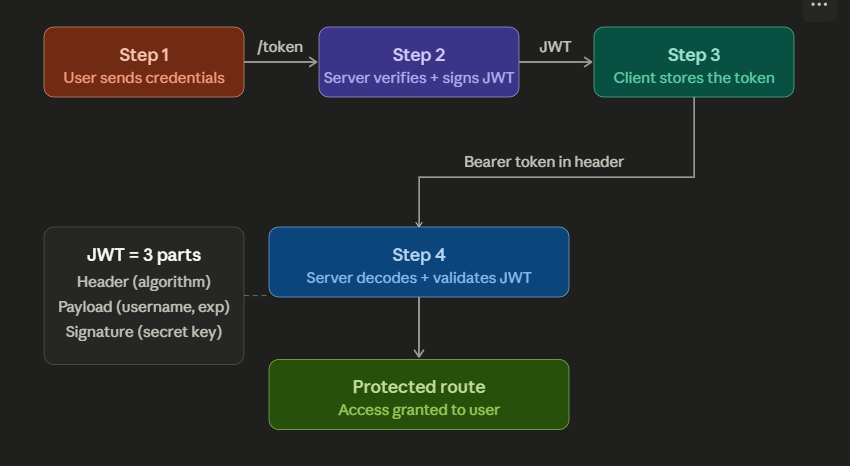

#### Analogy

Imagine a nightclub, when you arrive you show your id (username + password) at the enterance, the bouncer checks it and gives you a wristband (JWT Token). Now, for the rest of the night, you show the wristband to enter any vip area, and no one recheck for proof i mean id, username and password. and also the wrist band has expiry for tonight, and its tamper proof -- sealed with clubs stamp == secret key, if someone fakes the stamp, security instantly rejects it

jwt.encode ---> The bouncer stamping the wrist band
jwt.decode ----> security at the vip door reading and verifying the stamp

OAuth2PasswordBearer ---> the mechanism of chcking the wristband on each other

In [8]:
!pip install python-jose passlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 kB 6.0 MB/s eta 0:00:00


In [9]:
# ─── 1. SETUP ─────────────────────────────────────────────────────────────────
from fastapi import FastAPI, Depends, HTTPException
from fastapi.security import OAuth2PasswordBearer, OAuth2PasswordRequestForm
from passlib.context import CryptContext
from pydantic import BaseModel
from datetime import datetime, timedelta
import jwt  # pip install python-jose

In [10]:
app = FastAPI()

#the stamp machine -- only the server knows this key
SECRET_KEY = "mysecretkey"
ALGORITHM = "HS256"
TOKEN_EXPIRE_MINUTES = 30

In [12]:
from typing_extensions import deprecated
# THE DOOR- CHECKER: LOOKS FOR AUTHORIZATION
oauth2_schema = OAuth2PasswordBearer(tokenUrl = "token")
#password hasher, to encrypt the password
pwd_context = CryptContext(schemes=["bcrypt"],deprecated="auto")



In [14]:
#data models
class Token(BaseModel):
  access_token:str
  token_type:str

fake_users_db = {
    "johndoe":{
        "username":"johndoe",
        "password":pwd_context.hash("password123"),
        }
}

In [16]:
def verify_password(plain_password:str,hashed_password:str)->bool:
  return pwd_context.verify(plain_password,hashed_password)
  #bycrypt internally compare we will never unhash it

def create_access_token(username:str)->str:
  '''create a wrist band jwt stamped with the secret key'''
  payload = {
      "sub":username,
      "exp":datetime.utcnow() + timedelta(minutes=TOKEN_EXPIRE_MINUTES)
  }
  return jwt.encode(payload,SECRET_KEY,algorith=ALGORITHM)

In [20]:
#the token endpoint the bouncer desk
@app.post("/token",response_model=Token)
async def login(form_data:OAuth2PasswordRequestForm=Depends()):
  #check ig the user exitsts
  user = fake_user_db.get(form_data.username)
  #verify password if wrongg we give invalide cred
  # dont say user not found, that leaks info to attackers
  if not user or not verify_password(form_data.password,user["password"]):
    raise HTTPException(status_code=401,detail='invalid creds fuck off')

  #issue the jwt wrist band
  token = create_access_token(username=form_data.username)
  return {"access_token":token,"token_type":"bearer"}


In [21]:
#5 - dependency reads and validates the token on every protected request
def get_current_user(token:str=Depends(oauth2_schema))->str:
  '''This runs automatically on any route that uses get_current_user '''
  try:
    payload = jwt.decode(token,SECRET_KEY,algorithms=[ALGORITHM])
    username:str = payload.get("sub")
    if not username:
      raise ValueError("No username in token")
    return username
  except jwt.PyJWKError:
      raise HTTPException(
            status_code=401,
            detail="Could not validate credentials",
            headers={"WWW-Authenticate": "Bearer"},
      )


In [22]:
@app.get("/protected")
async def protected_route(current_user:str = Depends(get_current_user)):
  return {"message":f"hello,{current_user} You have acess!"}